Logistic Regression:
Accuracy = 0.9993328651685394
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56870
           1       0.91      0.64      0.75        90

    accuracy                           1.00     56960
   macro avg       0.95      0.82      0.88     56960
weighted avg       1.00      1.00      1.00     56960

Confusion Matrix:
 [[56864     6]
 [   32    58]]
ROC AUC Score = 0.9811087665826543


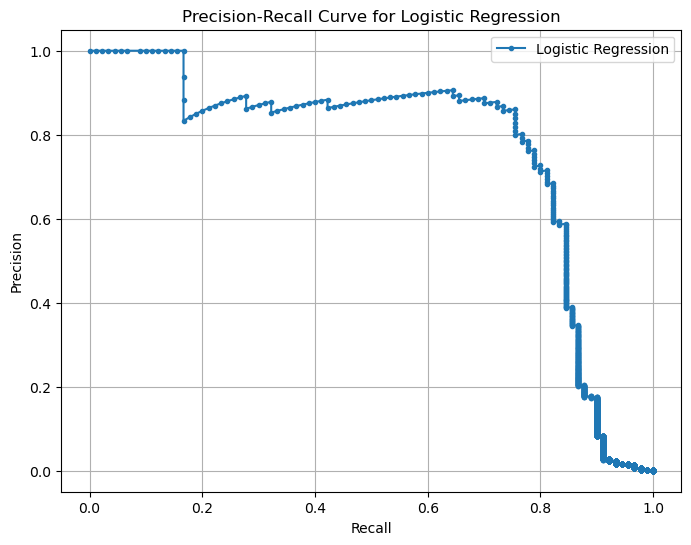

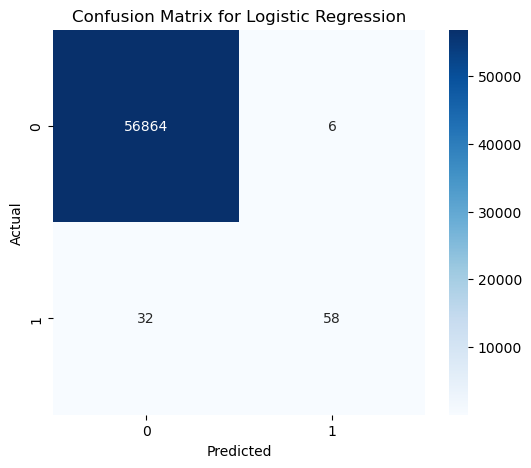

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, precision_recall_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# قراءة البيانات
train_data = pd.read_csv("data/train.csv")
test_data = pd.read_csv("data/val.csv")

# تقسيم البيانات إلى المدخلات والمخرجات
X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]
X_test = test_data.iloc[:, :-1]
y_test = test_data.iloc[:, -1]

# دالة لتطبيق StandardScaler
def Scaling(data):
    st = StandardScaler()
    return st.fit_transform(data)

# تدريب وتقييم نموذج Logistic Regression
def logistic_regression(X_train, y_train, X_test, y_test):
    # Scaling البيانات
    X_train_scaled = Scaling(X_train)
    X_test_scaled = Scaling(X_test)
    
    # تدريب نموذج الانحدار اللوجستي
    modelL = LogisticRegression(solver='lbfgs', max_iter=1000)
    modelL.fit(X_train_scaled, y_train)
    
    # التوقعات
    y_predict = modelL.predict(X_test_scaled)
    y_predictp = modelL.predict_proba(X_test_scaled)[:, 1]
    
    # طباعة نتائج النموذج
    print("Logistic Regression:")
    print("Accuracy =", accuracy_score(y_test, y_predict))
    print("Classification Report:\n", classification_report(y_test, y_predict))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict))
    print("ROC AUC Score =", roc_auc_score(y_test, y_predictp))
    
    # مرئيات: رسم Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_predictp)
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, marker='.', label='Logistic Regression')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve for Logistic Regression')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # مرئيات: رسم Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, y_predict), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix for Logistic Regression')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    joblib.dump(modelL, 'logistic_regression_model.pkl')

if __name__ == "__main__":
    logistic_regression(X_train, y_train, X_test, y_test)
